## Script to calculate the OD values and percentages in co_culture from CT values

This code is part of the article "Environmentally mediated interactions predict community assembly and invasion success in a gut microbiota SynCom". 

Authors:
P. Gadaleta, P.T. van Leeuwen, M.T. Wortel.

Prerequisites for this script to work is an excel document containing the columns: culture,	focal_species, in_vitro_ct, equation. The culture denotes the culture used, the focal species the species for which the CT value is denoted in the in_vitro_ct column. And finally the equation which should be given as Y = a*X + b in which Y is the CT value and X is the OD. This script will automatically calculate X but can be rewritten to solve for Y. 

Note that the equations should be calculated before with a standard curve. 


### installing packages and importing them

In [1]:
import numpy as np
import sympy as sp
import pandas as pd
import matplotlib.pyplot as plt

# Functions 

In [2]:
# Function to solve the equation for X, given Y
def solve_equation(equation, y_value):
    # Replace 'Y' with numeric value
    equation = equation.replace("Y", str(y_value))
    # Parse and build sympy equation
    lhs_str, rhs_str = [s.strip() for s in equation.split('=')]
    lhs, rhs = sp.sympify(lhs_str), sp.sympify(rhs_str)
    eq = sp.Eq(lhs, rhs)
    # Solve for X
    solution = sp.solve(eq, X)
    return solution[0] if solution else None

# Function to extract slope 'a' from Y = aX + b
def get_slope_from_equation(equation: str):
    lhs_str, rhs_str = [s.strip() for s in equation.split('=')]
    lhs, rhs = sp.sympify(lhs_str), sp.sympify(rhs_str)
    # Solve for Y
    solY = sp.solve(sp.Eq(lhs, rhs), Y)
    if not solY:
        raise ValueError("Equation cannot be solved for Y")
    # Expression for Y as function of X
    Y_expr = sp.simplify(solY[0])
    # Derivative wrt X = slope
    slope = sp.diff(Y_expr, X)
    return float(slope)

In [3]:
# Function to compute propagated std for two species
def propagate_std_two_species_transform(group_df):
    # Convert to floats
    x = group_df['solutions'].astype(float).values
    std_x = group_df['std_solutions'].astype(float).values

    # Propagate std
    sigma_y = np.sqrt(x[1]**2 * std_x[0]**2 + x[0]**2 * std_x[1]**2) / (x[0] + x[1])**2
    sigma_y_second = np.sqrt(x[0]**2 * std_x[1]**2 + x[1]**2 * std_x[0]**2) / (x[0] + x[1])**2

    return pd.Series([sigma_y, sigma_y_second], index=group_df.index)

In [4]:
def propagate_std_general(group_df):
    x = group_df['solutions'].astype(float).values
    std_x = group_df['std_solutions'].astype(float).values
    S = np.sum(x)

    propagated_stds = []
    for i in range(len(x)):
        # derivative wrt xi
        d_ri_d_xi = (S - x[i]) / (S**2)
        var_i = (d_ri_d_xi * std_x[i])**2

        # derivatives wrt other xj
        var_others = 0
        for j in range(len(x)):
            if j != i:
                d_ri_d_xj = -(x[i]) / (S**2)
                var_others += (d_ri_d_xj * std_x[j])**2

        sigma_ri = np.sqrt(var_i + var_others)
        propagated_stds.append(sigma_ri)

    return pd.Series(propagated_stds, index=group_df.index)


In [5]:
def propagate_std_general_pre(group_df):
    x = group_df['solutions_pre'].astype(float).values
    std_x = group_df['std_solutions_pre'].astype(float).values
    S = np.sum(x)

    propagated_stds = []
    for i in range(len(x)):
        # derivative wrt xi
        d_ri_d_xi = (S - x[i]) / (S**2)
        var_i = (d_ri_d_xi * std_x[i])**2

        # derivatives wrt other xj
        var_others = 0
        for j in range(len(x)):
            if j != i:
                d_ri_d_xj = -(x[i]) / (S**2)
                var_others += (d_ri_d_xj * std_x[j])**2

        sigma_ri = np.sqrt(var_i + var_others)
        propagated_stds.append(sigma_ri)

    return pd.Series(propagated_stds, index=group_df.index)

# Main

## Bi-Culture

In [6]:
# Load the Excel file
in_vitro_df = pd.read_csv("in_vitro_data_with_raw.csv")

# Display the first few rows of each DataFrame to verify
in_vitro_df.head()

,culture,focal_species,in_vitro_ct,equation,Bio1_T1,Bio1_T2,Bio2_T1,Bio2_T2,Bio3_T1,Bio3_T2,Bio4_T1,Bio4_T2,Bio1,Bio2,Bio3,Bio4,Avg,Std
0,['LJ' 'RI'],LJ,14.312,Y = -3.937*X + 16.98,14.4558,14.4406,14.1686,14.1836,14.4319,14.4180,14.1921,14.2060,14.44820,14.17610,14.42495,14.19905,14.312075,0.144378
1,['LJ' 'RI'],RI,6.560,Y = -1.021*X + 9.100,6.6191,6.6307,6.5011,6.4897,6.6059,6.5832,6.5141,6.5368,6.62490,6.49540,6.59455,6.52545,6.560075,0.059924
2,['LB' 'RI'],LB,18.379,Y = -4.402*X + 24.11,18.6126,18.5210,18.1468,18.2376,18.4616,18.5048,18.2964,18.2532,18.56680,18.19220,18.48320,18.27480,18.379250,0.175003
3,['LB' 'RI'],RI,5.979,Y = -1.021*X + 9.100,6.0381,6.0154,5.9201,5.9427,5.9987,6.0111,5.9593,5.9469,6.02675,5.93140,6.00490,5.95310,5.979037,0.044300
4,['LB' 'LJ'],LB,21.373,Y = -4.402*X + 24.11,21.4749,21.5663,21.2714,21.1803,21.4166,21.4925,21.3294,21.2535,21.52060,21.22585,21.45455,21.29145,21.373113,0.137525


### Solving the equations for X

In [7]:
# Define symbolic variables
X, Y = sp.symbols('X Y')

# Apply to your dataframe
in_vitro_df['solutions'] = in_vitro_df.apply(
    lambda row: solve_equation(row['equation'], row['in_vitro_ct']), axis=1
)

in_vitro_df['std_solutions'] = in_vitro_df['Std'] / abs(in_vitro_df.apply(
    lambda row: get_slope_from_equation(row['equation']), axis=1
))

in_vitro_df.head()


,culture,focal_species,in_vitro_ct,equation,Bio1_T1,Bio1_T2,Bio2_T1,Bio2_T2,Bio3_T1,Bio3_T2,Bio4_T1,Bio4_T2,Bio1,Bio2,Bio3,Bio4,Avg,Std,solutions,std_solutions
0,['LJ' 'RI'],LJ,14.312,Y = -3.937*X + 16.98,14.4558,14.4406,14.1686,14.1836,14.4319,14.4180,14.1921,14.2060,14.44820,14.17610,14.42495,14.19905,14.312075,0.144378,0.677673355346711,0.036672
1,['LJ' 'RI'],RI,6.560,Y = -1.021*X + 9.100,6.6191,6.6307,6.5011,6.4897,6.6059,6.5832,6.5141,6.5368,6.62490,6.49540,6.59455,6.52545,6.560075,0.059924,2.48775710088149,0.058691
2,['LB' 'RI'],LB,18.379,Y = -4.402*X + 24.11,18.6126,18.5210,18.1468,18.2376,18.4616,18.5048,18.2964,18.2532,18.56680,18.19220,18.48320,18.27480,18.379250,0.175003,1.30190822353476,0.039755
3,['LB' 'RI'],RI,5.979,Y = -1.021*X + 9.100,6.0381,6.0154,5.9201,5.9427,5.9987,6.0111,5.9593,5.9469,6.02675,5.93140,6.00490,5.95310,5.979037,0.044300,3.05680705190989,0.043389
4,['LB' 'LJ'],LB,21.373,Y = -4.402*X + 24.11,21.4749,21.5663,21.2714,21.1803,21.4166,21.4925,21.3294,21.2535,21.52060,21.22585,21.45455,21.29145,21.373113,0.137525,0.621762835074966,0.031242


### Calculating the percentages of each species in the culture and propagate the error

In [8]:
# Define the unique group columns
group_columns = ['culture']  # Replace 'Community_ID' with columns defining unique communities

# Calculate the total non_normalized_result per group
in_vitro_df['group_total'] = in_vitro_df.groupby(group_columns)['solutions'].transform('sum')

# Calculate the percentage for each focal species
in_vitro_df['percentage'] = (in_vitro_df['solutions'] / in_vitro_df['group_total']) * 100

# Optional: Drop the intermediate 'group_total' column if not needed
in_vitro_df = in_vitro_df.drop(columns=['group_total'])

in_vitro_df['percentage_std'] = in_vitro_df.groupby('culture').apply(
    propagate_std_two_species_transform
).reset_index(level=0, drop=True)  # Align index

in_vitro_df['percentage_std'] = in_vitro_df['percentage_std']* 100

in_vitro_df.head()

C:\Users\pgadale\AppData\Local\Temp\ipykernel_7124\244555735.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  in_vitro_df['percentage_std'] = in_vitro_df.groupby('culture').apply(


,culture,focal_species,in_vitro_ct,equation,Bio1_T1,Bio1_T2,Bio2_T1,Bio2_T2,Bio3_T1,Bio3_T2,...,Bio1,Bio2,Bio3,Bio4,Avg,Std,solutions,std_solutions,percentage,percentage_std
0,['LJ' 'RI'],LJ,14.312,Y = -3.937*X + 16.98,14.4558,14.4406,14.1686,14.1836,14.4319,14.4180,...,14.44820,14.17610,14.42495,14.19905,14.312075,0.144378,0.677673355346711,0.036672,21.4085687465773,0.993258
1,['LJ' 'RI'],RI,6.560,Y = -1.021*X + 9.100,6.6191,6.6307,6.5011,6.4897,6.6059,6.5832,...,6.62490,6.49540,6.59455,6.52545,6.560075,0.059924,2.48775710088149,0.058691,78.5914312534227,0.993258
2,['LB' 'RI'],LB,18.379,Y = -4.402*X + 24.11,18.6126,18.5210,18.1468,18.2376,18.4616,18.5048,...,18.56680,18.19220,18.48320,18.27480,18.379250,0.175003,1.30190822353476,0.039755,29.8690816275432,0.705383
3,['LB' 'RI'],RI,5.979,Y = -1.021*X + 9.100,6.0381,6.0154,5.9201,5.9427,5.9987,6.0111,...,6.02675,5.93140,6.00490,5.95310,5.979037,0.044300,3.05680705190989,0.043389,70.1309183724568,0.705383
4,['LB' 'LJ'],LB,21.373,Y = -4.402*X + 24.11,21.4749,21.5663,21.2714,21.1803,21.4166,21.4925,...,21.52060,21.22585,21.45455,21.29145,21.373113,0.137525,0.621762835074966,0.031242,35.9882882425841,1.457059


In [9]:
# Export the updated DataFrame to an Excel file
in_vitro_df.to_csv("in_vitro_df_with_solutions.csv", index=False)

## Tri and Quad Colture

### First Batch

In [10]:
# Load the Excel file
in_vitro_df_triquad = pd.read_excel("in_vitro_data_raw_triquad.xlsx", nrows=30)

# Display the first few rows of each DataFrame to verify
print("in_vitro dataframe")
in_vitro_df_triquad.head()

in_vitro dataframe


,culture,focal_spec,equation,Bio1_T1,Bio1_T2,Bio2_T1,Bio2_T2,Bio1_avg,Bio2_avg,Bio1_std,Bio2_std,Unnamed: 11,in_vitro_ct,Std,Community
0,['AM' 'EC' 'FP' 'LJ' ],AM,Y = -2.536*X + 23.01,22.5029,22.8050,22.2374,22.6169,22.65395,22.42715,0.213617,0.268347,0.240982,22.540550,0.160372,1
1,['AM' 'EC' 'FP' 'LJ' ],EC,Y = -4.708*X + 16.81,16.4275,16.5457,16.1585,16.5106,16.48660,16.33455,0.083580,0.248972,0.166276,16.410575,0.107516,1
2,['AM' 'EC' 'FP' 'LJ' ],FP,Y = -2.274*X + 22.44,21.4321,21.6432,21.1809,21.5371,21.53765,21.35900,0.149270,0.251871,0.200571,21.448325,0.126325,1
3,['AM' 'EC' 'FP' 'LJ' ],LJ,Y = -3.937*X + 16.98,16.2909,16.3571,16.1295,16.2473,16.32400,16.18840,0.046810,0.083297,0.065054,16.256200,0.095884,1
4,['AM' 'EC' 'LJ' 'LB' ],AM,Y = -2.536*X + 23.01,21.9762,22.3930,22.0024,22.3108,22.18460,22.15660,0.294722,0.218072,0.256397,22.170600,0.019799,2


In [11]:
# Define symbolic variables
X, Y = sp.symbols('X Y')

# Apply to your dataframe
in_vitro_df_triquad['solutions'] = in_vitro_df_triquad.apply(
    lambda row: solve_equation(row['equation'], row['in_vitro_ct']), axis=1
)

in_vitro_df_triquad['std_solutions'] = in_vitro_df_triquad['Std'] / abs(in_vitro_df_triquad.apply(
    lambda row: get_slope_from_equation(row['equation']), axis=1
))

in_vitro_df_triquad.head()

,culture,focal_spec,equation,Bio1_T1,Bio1_T2,Bio2_T1,Bio2_T2,Bio1_avg,Bio2_avg,Bio1_std,Bio2_std,Unnamed: 11,in_vitro_ct,Std,Community,solutions,std_solutions
0,['AM' 'EC' 'FP' 'LJ' ],AM,Y = -2.536*X + 23.01,22.5029,22.8050,22.2374,22.6169,22.65395,22.42715,0.213617,0.268347,0.240982,22.540550,0.160372,1,0.185114353312302,0.063238
1,['AM' 'EC' 'FP' 'LJ' ],EC,Y = -4.708*X + 16.81,16.4275,16.5457,16.1585,16.5106,16.48660,16.33455,0.083580,0.248972,0.166276,16.410575,0.107516,1,0.0848396346644010,0.022837
2,['AM' 'EC' 'FP' 'LJ' ],FP,Y = -2.274*X + 22.44,21.4321,21.6432,21.1809,21.5371,21.53765,21.35900,0.149270,0.251871,0.200571,21.448325,0.126325,1,0.436092788038698,0.055552
3,['AM' 'EC' 'FP' 'LJ' ],LJ,Y = -3.937*X + 16.98,16.2909,16.3571,16.1295,16.2473,16.32400,16.18840,0.046810,0.083297,0.065054,16.256200,0.095884,1,0.183845567691135,0.024355
4,['AM' 'EC' 'LJ' 'LB' ],AM,Y = -2.536*X + 23.01,21.9762,22.3930,22.0024,22.3108,22.18460,22.15660,0.294722,0.218072,0.256397,22.170600,0.019799,2,0.330993690851735,0.007807


In [12]:
# Define the unique group columns
group_columns = ['culture']  # Replace 'Community_ID' with columns defining unique communities

# Calculate the total non_normalized_result per group
in_vitro_df_triquad['group_total'] = in_vitro_df_triquad.groupby(group_columns)['solutions'].transform('sum')

# Calculate the percentage for each focal species
in_vitro_df_triquad['percentage'] = (in_vitro_df_triquad['solutions'] / in_vitro_df_triquad['group_total']) * 100

# Optional: Drop the intermediate 'group_total' column if not needed
in_vitro_df_triquad = in_vitro_df_triquad.drop(columns=['group_total'])
in_vitro_df_triquad.head()

,culture,focal_spec,equation,Bio1_T1,Bio1_T2,Bio2_T1,Bio2_T2,Bio1_avg,Bio2_avg,Bio1_std,Bio2_std,Unnamed: 11,in_vitro_ct,Std,Community,solutions,std_solutions,percentage
0,['AM' 'EC' 'FP' 'LJ' ],AM,Y = -2.536*X + 23.01,22.5029,22.8050,22.2374,22.6169,22.65395,22.42715,0.213617,0.268347,0.240982,22.540550,0.160372,1,0.185114353312302,0.063238,20.8018817805840
1,['AM' 'EC' 'FP' 'LJ' ],EC,Y = -4.708*X + 16.81,16.4275,16.5457,16.1585,16.5106,16.48660,16.33455,0.083580,0.248972,0.166276,16.410575,0.107516,1,0.0848396346644010,0.022837,9.53369643692304
2,['AM' 'EC' 'FP' 'LJ' ],FP,Y = -2.274*X + 22.44,21.4321,21.6432,21.1809,21.5371,21.53765,21.35900,0.149270,0.251871,0.200571,21.448325,0.126325,1,0.436092788038698,0.055552,49.0051174305316
3,['AM' 'EC' 'FP' 'LJ' ],LJ,Y = -3.937*X + 16.98,16.2909,16.3571,16.1295,16.2473,16.32400,16.18840,0.046810,0.083297,0.065054,16.256200,0.095884,1,0.183845567691135,0.024355,20.6593043519614
4,['AM' 'EC' 'LJ' 'LB' ],AM,Y = -2.536*X + 23.01,21.9762,22.3930,22.0024,22.3108,22.18460,22.15660,0.294722,0.218072,0.256397,22.170600,0.019799,2,0.330993690851735,0.007807,36.9735255155748


In [13]:
# Apply per community
in_vitro_df_triquad['percentage_std'] = (
    in_vitro_df_triquad.groupby('culture')
    .apply(propagate_std_general)
    .reset_index(level=0, drop=True)
)

# Scale to percentage
in_vitro_df_triquad['percentage_std'] *= 100

in_vitro_df_triquad[['culture', 'focal_spec', 'solutions', 'percentage', 'percentage_std']].head()


C:\Users\pgadale\AppData\Local\Temp\ipykernel_7124\2592680144.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(propagate_std_general)


,culture,focal_spec,solutions,percentage,percentage_std
0,['AM' 'EC' 'FP' 'LJ' ],AM,0.185114353312302,20.8018817805840,5.828382
1,['AM' 'EC' 'FP' 'LJ' ],EC,0.0848396346644010,9.53369643692304,2.504200
2,['AM' 'EC' 'FP' 'LJ' ],FP,0.436092788038698,49.0051174305316,5.063737
3,['AM' 'EC' 'FP' 'LJ' ],LJ,0.183845567691135,20.6593043519614,2.968934
4,['AM' 'EC' 'LJ' 'LB' ],AM,0.330993690851735,36.9735255155748,1.439175


In [14]:
# Export the updated DataFrame to an Excel file
in_vitro_df_triquad.to_csv("in_vitro_df_triquad_with_solutions.csv", index=False)

### Second Batch

In [15]:
# Load the Excel file
in_vitro_df_triquad_second = pd.read_excel("in_vitro_data_raw_triquad_second.xlsx", nrows=15)

# Display the first few rows of each DataFrame to verify
print("in_vitro dataframe")
in_vitro_df_triquad_second.head()

in_vitro dataframe


,Community,Species,equation,Bio1_T1,Bio1_T2,Bio2_T1,Bio2_T2,Bio1,Bio2,Avg_bio,Std_bio
0,1,BT,Y = -4.826*X + 20.31,18.1529,18.1574,18.1361,18.2105,18.15515,18.17330,18.164225,0.009075
1,1,EC,Y = -4.708*X + 16.81,15.4074,15.4541,15.3945,15.5240,15.43075,15.45925,15.445000,0.014250
2,1,LJ,Y = -3.937*X + 16.98,16.2002,16.2037,16.1851,16.2519,16.20195,16.21850,16.210225,0.008275
3,2,AM,Y = -2.536*X + 23.01,22.1362,22.3374,22.1200,22.2334,22.23680,22.17670,22.206750,0.030050
4,2,EC,Y = -4.708*X + 16.81,14.6961,14.7211,14.6847,14.8309,14.70860,14.75780,14.733200,0.024600


In [16]:
in_vitro_df_triquad_second['solutions'] = in_vitro_df_triquad_second.apply(
    lambda row: max(0, solve_equation(row['equation'], row['Avg_bio'])),
    axis=1
)

in_vitro_df_triquad_second['std_solutions'] = in_vitro_df_triquad_second['Std_bio'] / abs(in_vitro_df_triquad_second.apply(
    lambda row: get_slope_from_equation(row['equation']), axis=1
))

in_vitro_df_triquad_second.head()

,Community,Species,equation,Bio1_T1,Bio1_T2,Bio2_T1,Bio2_T2,Bio1,Bio2,Avg_bio,Std_bio,solutions,std_solutions
0,1,BT,Y = -4.826*X + 20.31,18.1529,18.1574,18.1361,18.2105,18.15515,18.17330,18.164225,0.009075,0.444628056361376,0.001880
1,1,EC,Y = -4.708*X + 16.81,15.4074,15.4541,15.3945,15.5240,15.43075,15.45925,15.445000,0.014250,0.289932030586236,0.003027
2,1,LJ,Y = -3.937*X + 16.98,16.2002,16.2037,16.1851,16.2519,16.20195,16.21850,16.210225,0.008275,0.195523241046482,0.002102
3,2,AM,Y = -2.536*X + 23.01,22.1362,22.3374,22.1200,22.2334,22.23680,22.17670,22.206750,0.030050,0.316738958990536,0.011849
4,2,EC,Y = -4.708*X + 16.81,14.6961,14.7211,14.6847,14.8309,14.70860,14.75780,14.733200,0.024600,0.441121495327103,0.005225


In [17]:
# Define the unique group columns
group_columns = ['Community']  # Replace 'Community_ID' with columns defining unique communities

# Calculate the total non_normalized_result per group
in_vitro_df_triquad_second['group_total'] = in_vitro_df_triquad_second.groupby(group_columns)['solutions'].transform('sum')

# Calculate the percentage for each focal species
in_vitro_df_triquad_second['percentage'] = (in_vitro_df_triquad_second['solutions'] / in_vitro_df_triquad_second['group_total']) * 100

# Optional: Drop the intermediate 'group_total' column if not needed
in_vitro_df_triquad_second = in_vitro_df_triquad_second.drop(columns=['group_total'])


In [18]:
# Apply per community
in_vitro_df_triquad_second['percentage_std'] = (
    in_vitro_df_triquad_second.groupby('Community')
    .apply(propagate_std_general)
    .reset_index(level=0, drop=True)
)

# Scale to percentage
in_vitro_df_triquad_second['percentage_std'] *= 100

in_vitro_df_triquad_second[['Community', 'Species', 'solutions', 'percentage', 'percentage_std']].head()

C:\Users\pgadale\AppData\Local\Temp\ipykernel_7124\1443025659.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(propagate_std_general)


,Community,Species,solutions,percentage,percentage_std
0,1,BT,0.444628056361376,47.8051850816747,0.216817
1,1,EC,0.289932030586236,31.1726940866181,0.243112
2,1,LJ,0.195523241046482,21.0221208317072,0.195809
3,2,AM,0.316738958990536,33.5454670448149,0.860289
4,2,EC,0.441121495327103,46.7186816279740,0.671059


In [19]:
# Export the updated DataFrame to an Excel file
in_vitro_df_triquad_second.to_csv("in_vitro_df_second_with_solutions.csv", index=False)

## Invasion Cultures

In [20]:
# Load the Excel file
in_vitro_df_invasion = pd.read_excel("invasion prediction results.xlsx", nrows=47)

# Display the first few rows of each DataFrame to verify
print("in_vitro dataframe")
in_vitro_df_invasion.head()

in_vitro dataframe


,Consortium,Species,equation,Bio1_T1,Bio1_T2,Bio1_T3,Bio2_T1,Bio2_T2,Bio2_T3,Bio3_T1,...,Avg_Bio1,Avg_Bio2,Avg_Bio3,Avg Post Invasion,Std Post Invasion,Avg_Bio1.1,Avg_Bio2.1,Avg_Bio3.1,Avg Pre Invasion,Std Pre Invasion
0,1,BOV,Y = -2.401*X + 10.82,10.2257,10.3088,10.2104,10.2601,10.3069,10.2483,10.2412,...,10.2483,10.271767,10.232333,10.250800,0.016195,10.834467,10.910933,10.828500,10.857967,0.037532
1,1,LB,Y = -4.402*X + 24.11,16.6352,16.7498,16.6181,16.7725,16.8947,16.7108,16.6783,...,16.6677,16.792667,16.660133,16.706833,0.060772,20.630133,20.722333,20.605933,20.652800,0.050150
2,1,LJ,Y = -3.937*X + 16.98,12.2721,12.3235,12.2558,12.3015,12.4833,12.2970,12.2803,...,12.2838,12.360600,12.270067,12.304822,0.039837,13.866833,13.925033,13.855400,13.882422,0.030490
3,2,BOV,Y = -2.401*X + 10.82,10.2942,10.3025,10.2895,10.3488,10.3832,10.3109,10.2921,...,10.2954,10.347633,10.296300,10.313111,0.024414,10.844967,10.918067,10.825533,10.862856,0.039838
4,2,FP,Y = -2.274*X + 22.44,19.4888,19.4896,19.4787,19.6270,19.8612,19.5082,19.5317,...,19.4857,19.665467,19.487700,19.546289,0.084275,20.145500,20.288467,20.102167,20.178711,0.079600


In [21]:
# Define symbolic variables
X, Y = sp.symbols('X Y')

# Apply to your dataframe
in_vitro_df_invasion['solutions'] = in_vitro_df_invasion.apply(
    lambda row: max(0,solve_equation(row['equation'], row['Avg Post Invasion'])), axis=1
)

in_vitro_df_invasion['std_solutions'] = in_vitro_df_invasion['Std Post Invasion'] / abs(in_vitro_df_invasion.apply(
    lambda row: get_slope_from_equation(row['equation']), axis=1
))

# Apply to your dataframe
in_vitro_df_invasion['solutions_pre'] = in_vitro_df_invasion.apply(
    lambda row: max(0.01,solve_equation(row['equation'], row['Avg Pre Invasion'])), axis=1
)

in_vitro_df_invasion['std_solutions_pre'] = in_vitro_df_invasion['Std Pre Invasion'] / abs(in_vitro_df_invasion.apply(
    lambda row: get_slope_from_equation(row['equation']), axis=1
))

in_vitro_df_invasion.head()

,Consortium,Species,equation,Bio1_T1,Bio1_T2,Bio1_T3,Bio2_T1,Bio2_T2,Bio2_T3,Bio3_T1,...,Std Post Invasion,Avg_Bio1.1,Avg_Bio2.1,Avg_Bio3.1,Avg Pre Invasion,Std Pre Invasion,solutions,std_solutions,solutions_pre,std_solutions_pre
0,1,BOV,Y = -2.401*X + 10.82,10.2257,10.3088,10.2104,10.2601,10.3069,10.2483,10.2412,...,0.016195,10.834467,10.910933,10.828500,10.857967,0.037532,0.237067888379842,0.006745,0.01,0.015632
1,1,LB,Y = -4.402*X + 24.11,16.6352,16.7498,16.6181,16.7725,16.8947,16.7108,16.6783,...,0.060772,20.630133,20.722333,20.605933,20.652800,0.050150,1.68177343631683,0.013806,0.785370286233530,0.011393
2,1,LJ,Y = -3.937*X + 16.98,12.2721,12.3235,12.2558,12.3015,12.4833,12.2970,12.2803,...,0.039837,13.866833,13.925033,13.855400,13.882422,0.030490,1.18749753055062,0.010119,0.786786329128214,0.007744
3,2,BOV,Y = -2.401*X + 10.82,10.2942,10.3025,10.2895,10.3488,10.3832,10.3109,10.2921,...,0.024414,10.844967,10.918067,10.825533,10.862856,0.039838,0.211115738812532,0.010168,0.01,0.016592
4,2,FP,Y = -2.274*X + 22.44,19.4888,19.4896,19.4787,19.6270,19.8612,19.5082,19.5317,...,0.084275,20.145500,20.288467,20.102167,20.178711,0.079600,1.27252027753347,0.037060,0.994410241375941,0.035004


In [22]:
# Define the unique group columns
group_columns = ['Consortium']  # Replace 'Community_ID' with columns defining unique communities

# Calculate the total non_normalized_result per group
in_vitro_df_invasion['group_total_post'] = in_vitro_df_invasion.groupby(group_columns)['solutions'].transform('sum')

# Calculate the percentage for each focal species
in_vitro_df_invasion['percentage_post'] = (in_vitro_df_invasion['solutions'] / in_vitro_df_invasion['group_total_post']) * 100

# Apply per community
in_vitro_df_invasion['percentage_post_std'] = (
    in_vitro_df_invasion.groupby('Consortium')
    .apply(propagate_std_general)
    .reset_index(level=0, drop=True)
)
in_vitro_df_invasion['percentage_post_std'] *= 100

# Optional: Drop the intermediate 'group_total' column if not needed
in_vitro_df_invasion = in_vitro_df_invasion.drop(columns=['group_total_post'])

# Calculate the total non_normalized_result per group
in_vitro_df_invasion['group_total_pre'] = in_vitro_df_invasion.groupby(group_columns)['solutions_pre'].transform('sum')

# Calculate the percentage for each focal species
in_vitro_df_invasion['percentage_pre'] = (in_vitro_df_invasion['solutions_pre'] / in_vitro_df_invasion['group_total_pre']) * 100
# Apply per community
in_vitro_df_invasion['percentage_pre_std'] = (
    in_vitro_df_invasion.groupby('Consortium')
    .apply(propagate_std_general_pre)
    .reset_index(level=0, drop=True)
)
in_vitro_df_invasion['percentage_pre_std'] *= 100
# Optional: Drop the intermediate 'group_total' column if not needed
in_vitro_df_invasion = in_vitro_df_invasion.drop(columns=['group_total_pre'])
in_vitro_df_invasion.head()

C:\Users\pgadale\AppData\Local\Temp\ipykernel_7124\1654725496.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(propagate_std_general)
C:\Users\pgadale\AppData\Local\Temp\ipykernel_7124\1654725496.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(propagate_std_general_pre)


,Consortium,Species,equation,Bio1_T1,Bio1_T2,Bio1_T3,Bio2_T1,Bio2_T2,Bio2_T3,Bio3_T1,...,Avg Pre Invasion,Std Pre Invasion,solutions,std_solutions,solutions_pre,std_solutions_pre,percentage_post,percentage_post_std,percentage_pre,percentage_pre_std
0,1,BOV,Y = -2.401*X + 10.82,10.2257,10.3088,10.2104,10.2601,10.3069,10.2483,10.2412,...,10.857967,0.037532,0.237067888379842,0.006745,0.01,0.015632,7.63174590497049,0.204934,0.632048679815026,0.981784
1,1,LB,Y = -4.402*X + 24.11,16.6352,16.7498,16.6181,16.7725,16.8947,16.7108,16.6783,...,20.652800,0.050150,1.68177343631683,0.013806,0.785370286233530,0.011393,54.1400508665030,0.294047,49.6392252579852,0.656562
2,1,LJ,Y = -3.937*X + 16.98,12.2721,12.3235,12.2558,12.3015,12.4833,12.2970,12.2803,...,13.882422,0.030490,1.18749753055062,0.010119,0.786786329128214,0.007744,38.2282032285265,0.276124,49.7287260621998,0.655877
3,2,BOV,Y = -2.401*X + 10.82,10.2942,10.3025,10.2895,10.3488,10.3832,10.3109,10.2921,...,10.862856,0.039838,0.211115738812532,0.010168,0.01,0.016592,7.34459809180362,0.341838,0.521446455013092,0.860741
4,2,FP,Y = -2.274*X + 22.44,19.4888,19.4896,19.4787,19.6270,19.8612,19.5082,19.5317,...,20.178711,0.079600,1.27252027753347,0.037060,0.994410241375941,0.035004,44.2702664174791,0.746621,51.8531695194198,0.988904


In [23]:
# Export the updated DataFrame to an Excel file
in_vitro_df_invasion.to_csv("in_vitro_df_invasion_with_solutions.csv", index=False)

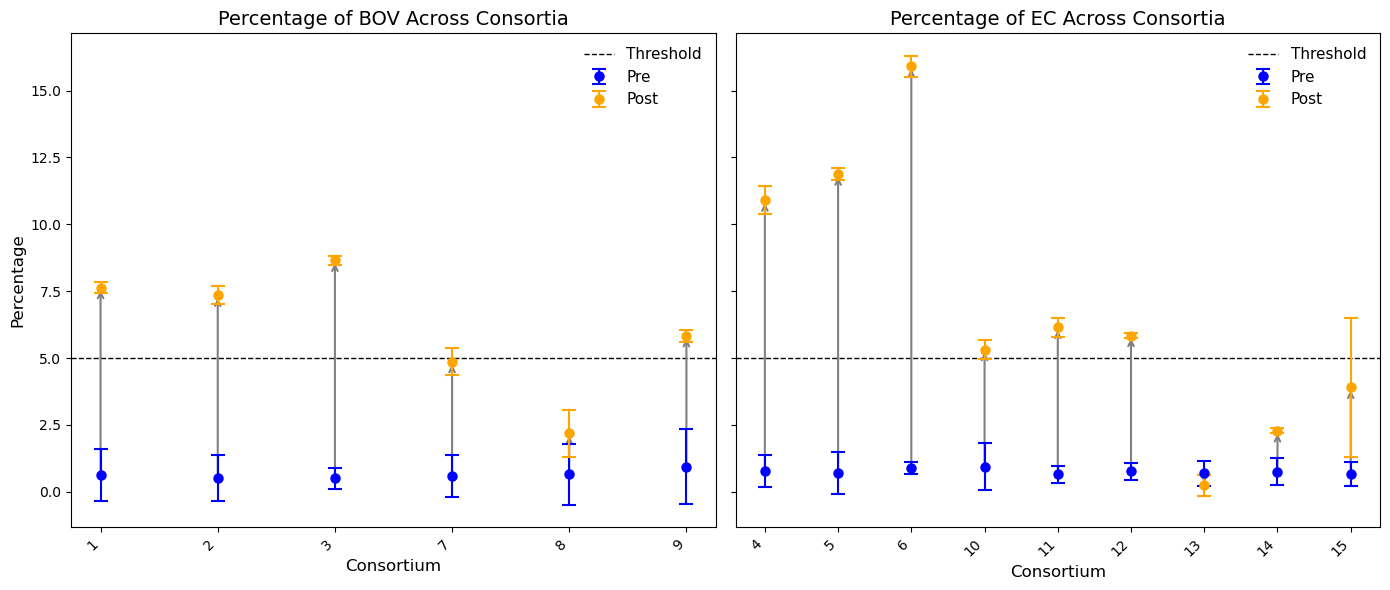

In [24]:
species_of_interest = ['BOV', 'EC']
df_plot = in_vitro_df_invasion[in_vitro_df_invasion['Species'].isin(species_of_interest)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for i, species in enumerate(species_of_interest):
    df_species = df_plot[df_plot['Species'] == species].copy()
    df_species = df_species.sort_values('Consortium')
    x = range(len(df_species))

    # Plot "Pre"
    pre_line = axes[i].errorbar(
        x, df_species['percentage_pre'],
        yerr=df_species['percentage_pre_std'],
        fmt='o', color='blue', label='Pre', zorder=3,
        capsize=5, elinewidth=1.5, markeredgewidth=1.5
    )

    # Plot "Post"
    post_line = axes[i].errorbar(
        x, df_species['percentage_post'],
        yerr=df_species['percentage_post_std'],
        fmt='o', color='orange', label='Post', zorder=3,
        capsize=5, elinewidth=1.5, markeredgewidth=1.5
    )

    # Horizontal threshold line
    threshold_line = axes[i].axhline(y=5, color='black', linestyle='--', linewidth=1, label='Threshold')

    # Plot arrows from Pre → Post
    for xi, pre, post in zip(x, df_species['percentage_pre'], df_species['percentage_post']):
        axes[i].annotate(
            '',
            xy=(xi, post),
            xytext=(xi, pre),
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5),
            zorder=2
        )

    # Axis labels and title
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(df_species['Consortium'], rotation=45, ha='right')
    axes[i].set_title(f'Percentage of {species} Across Consortia', fontsize=14)
    axes[i].set_xlabel('Consortium', fontsize=12)

    # Clean legend: only show once per subplot
    handles, labels = axes[i].get_legend_handles_labels()
    axes[i].legend(handles, labels, loc='upper right', frameon=False, fontsize=11)

# Shared y-axis label
axes[0].set_ylabel('Percentage', fontsize=12)

plt.tight_layout()
plt.show()
